In [ ]:
# Download the preprocessed data
# read the data
# divide data into X and y
# appli train test split

**Step-1: Read the preprocessed data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv('preprocessd_data.csv')
data.head()

,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,weekly_max_night_mins,videos_watched,customer_support_calls,churn
0,0,-0.264643,-0.946659,0,0,-1.508785,0.722258,-0.944404,-1.403000,-0.415473,0
1,0,0.029654,1.235009,0,0,0.304821,-0.901748,-0.688523,-0.599124,0.347522,0
2,0,2.580235,0.658246,0,0,-2.266627,0.613991,-0.483818,-1.403000,2.636507,1
3,0,-1.441834,0.783629,0,1,0.638123,-0.252146,0.079121,-0.197185,1.110517,0
4,0,0.127754,2.288228,0,0,-0.333851,0.253101,-0.893228,1.008630,-0.415473,0


**Step-2: Divide data into X and y**

In [3]:
data.shape

(3406, 11)

In [4]:
data.columns

Index(['gender', 'age', 'no_of_days_subscribed', 'multi_screen',
       'mail_subscribed', 'weekly_mins_watched', 'minimum_daily_mins',
       'weekly_max_night_mins', 'videos_watched', 'customer_support_calls',
       'churn'],
      dtype='object')

In [5]:
# Churn is the target column
X=data.drop('churn',axis=1)
y=data['churn']
X.shape,y.shape

((3406, 10), (3406,))

**Step-3: Train test split**

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2724, 10), (682, 10), (2724,), (682,))

# Model Development With out Hyper parameter Tuning

**Decision tree**

**Step-4: Read and develop the model**

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)


DecisionTreeClassifier()

**Step-5: Visualize the model**

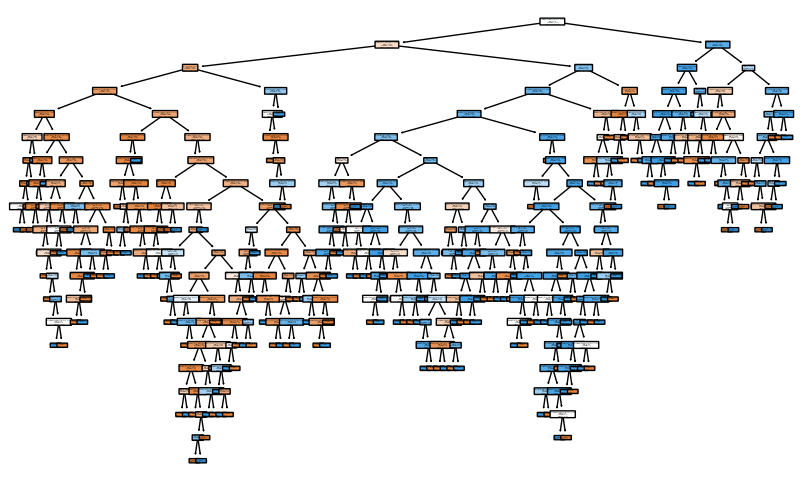

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.figure(figsize=(10,6))
plot_tree(dt, 
          feature_names=X.columns,
          filled=True,
          rounded=True)
plt.show()

**Step-6: Prediction on test data**



In [9]:
# Model name varaible: dt
# which data need to pass : X_test
y_predictions=dt.predict(X_test)
y_predictions

array([0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,

**Step-7: Compare with y_test**

In [10]:
# y_test is a series so convert into values
# y_predictions already a array of values
print(y_test.values[:10])
print(y_predictions[:10])

[0 1 1 1 1 0 1 1 0 1]
[0 0 1 1 1 0 1 1 0 1]


**Step-8:Create a Predictions Dataframe**

- Consider y_test as **Ground_Truth_data**

- Considet y_predictions as **Model_Predictions**

In [11]:
predictions_df=pd.DataFrame()
predictions_df['Ground_Truth_data']=y_test
predictions_df['Model_predictions']=y_predictions
l=[1 if i==j else 0 for i,j in zip(y_test,y_predictions)]
predictions_df['Match_NotMatch']=l
accuracy=np.sum(predictions_df['Match_NotMatch'])/len(predictions_df)
accuracy

0.873900293255132

In [12]:
predictions_df

,Ground_Truth_data,Model_predictions,Match_NotMatch
697,0,0,1
268,1,0,0
2055,1,1,1
114,1,1,1
1137,1,1,1
...,...,...,...
2698,1,1,1
1642,0,0,1
1635,0,0,1
739,0,0,1


**Step-9: Metrics**

In [13]:
from sklearn.metrics import accuracy_score,precision_score,recall_score, \
                            f1_score,confusion_matrix,ConfusionMatrixDisplay,\
                            roc_auc_score,auc

$ConfusionMatrix$

In [14]:
# we need to pass two arguments
# y_true=y_test, y_pred= y_predictions
confusion_matrix(y_test,y_predictions)

array([[296,  48],
       [ 38, 300]], dtype=int64)

In [15]:
tn, fp, fn, tp=confusion_matrix(y_test,y_predictions).ravel()
print('true postives are:',tp)
print('true negatives are:',tn)
print('False postives are:',fp)
print('False negatives are:',fn)

true postives are: 300
true negatives are: 296
False postives are: 48
False negatives are: 38


$ConfusionMatrixDisplay$

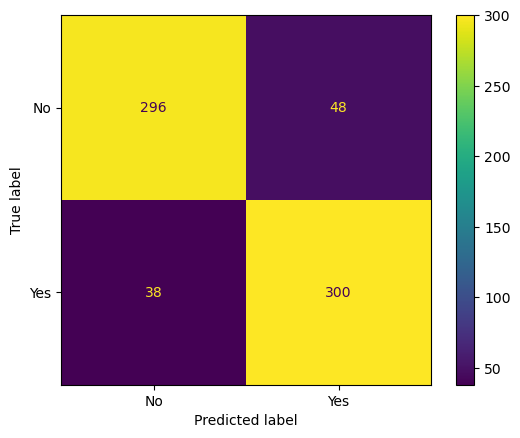

In [16]:
cmt=confusion_matrix(y_test,y_predictions)
disp=ConfusionMatrixDisplay(cmt,display_labels=['No','Yes'])
disp.plot()

$Precision$-$Recall$-$F1score$-$accuracy$

In [17]:
pr=round(precision_score(y_test,y_predictions),2)
rc=round(recall_score(y_test,y_predictions),2)
acc=round(accuracy_score(y_test,y_predictions),2)
f1=round(f1_score(y_test,y_predictions),2)
print('The precsion score is:',pr)
print('The recall score is:',rc)
print('The accuracy is:',acc)
print('The f1score is:',f1)

The precsion score is: 0.86
The recall score is: 0.89
The accuracy is: 0.87
The f1score is: 0.87


In [18]:
dt_metrics=[pr,rc,acc,f1]
Metrics_df=pd.DataFrame(dt_metrics,
                        index=['Precision','Recall','Accuracy','F1score'],
                        columns=['Decision Tree'],
                        )
Metrics_df

,Decision Tree
Precision,0.86
Recall,0.89
Accuracy,0.87
F1score,0.87


**ROC-AUC curve**

- Roc auc curve is a Graph between fpr vs tpr

- Graph between (1-specificity) vs sensitivity

- It will concentrate on TP means postive cases

- ROC AUC curve develop on probabilities

- we already know before we get direct predictions a probabilites will generate

- we have a method **dt.predict_proba**  will give probabilites

**Predict proba**

In [51]:
# first get all class probabilities
# It will give two probability values for each observation
# Fisrt column is No probability, second column yes probability
# ROC AUC curve develop using Yes probability cases
prob_yes=dt.predict_proba(X_test)[:,1]
prob_yes
# NO  YES        F
# 1   0     ---- No (0)
# 1   0     ----- No(0)
# 0   1    ------ yes(1)
# 0   1    ------ yes (1)
# 0   1            yes(1)

array([0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1.,
       0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0.,
       1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1.,
       1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1.,
       1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1.,
       1., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0.,
       0., 0., 1., 0., 0.

In [49]:
dt.predict(X_test)

array([0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,

**roc curve**

- roc curve expects two arguments

    - y_true here = y_test

    - y_score   = yes probabilities

fpr: [0.         0.13953488 1.        ]
tpr: [0.         0.88757396 1.        ]


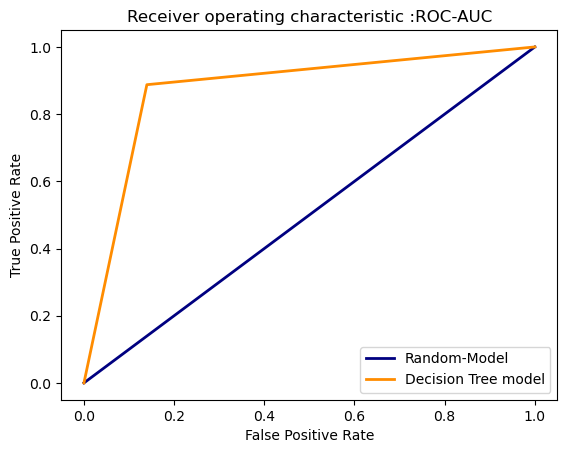

In [41]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_test,prob_yes)
print('fpr:',fpr)
print('tpr:',tpr)
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision Tree model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()

**AUC**

In [43]:
auc_score=auc(fpr,tpr)
print('The Auc score is:',auc_score)

The Auc score is: 0.8740195403880555


In [20]:
dt.predict(X_test)

array([0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,

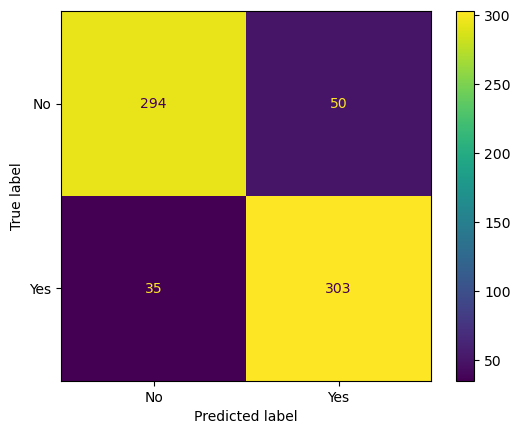

The precsion score is: 0.86
The recall score is: 0.9
The accuracy is: 0.88
The f1score is: 0.88
fpr: [0.         0.14534884 1.        ]
tpr: [0.        0.8964497 1.       ]


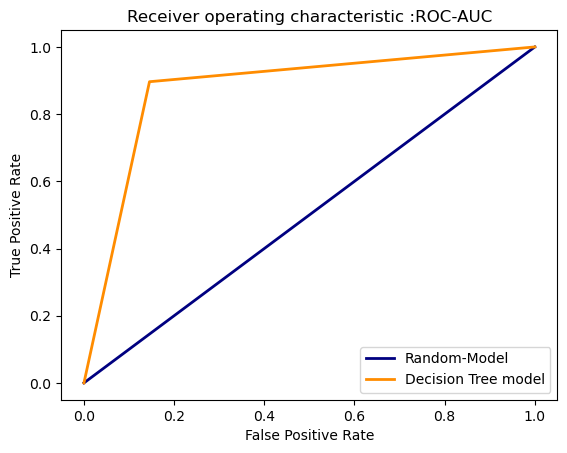

,Decision Tree
Precision,0.86
Recall,0.90
Accuracy,0.88
F1score,0.88


In [46]:
################## import packages #####################
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score, \
                            f1_score,confusion_matrix,ConfusionMatrixDisplay,\
                            roc_auc_score,auc,roc_curve

################# Develop the model #############################
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

################## Predictions ############################
y_predictions=dt.predict(X_test)
y_predictions

################ Metrics ###################################

############ Confusion matrix #####################################

cmt=confusion_matrix(y_test,y_predictions)
disp=ConfusionMatrixDisplay(cmt,display_labels=['No','Yes'])
disp.plot()
plt.show()

####################### Important Metrics ####################

pr=round(precision_score(y_test,y_predictions),2)
rc=round(recall_score(y_test,y_predictions),2)
acc=round(accuracy_score(y_test,y_predictions),2)
f1=round(f1_score(y_test,y_predictions),2)
print('The precsion score is:',pr)
print('The recall score is:',rc)
print('The accuracy is:',acc)
print('The f1score is:',f1)
#################### Roc AUC curve #######################
prob_yes=dt.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_test,prob_yes)
print('fpr:',fpr)
print('tpr:',tpr)
plt.plot([0,1],[0,1],color="navy",lw=2,label="Random-Model")
plt.plot(fpr,tpr,color="darkorange",lw=2, label="Decision Tree model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic :ROC-AUC")
plt.legend()
plt.show()



##############################################################
dt_metrics=[pr,rc,acc,f1]
Metrics_df=pd.DataFrame(dt_metrics,
                        index=['Precision','Recall','Accuracy','F1score'],
                        columns=['Decision Tree'],
                        )
Metrics_df

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier